Phase 1: Running FEA for all conditions (this may take a minute)...
  -> Solving HH17 UNIFORM...
Number of nodes: 1600
Number of elements: 1501
Number of equations: 3159
Duration for system solution: 0:00:00.553466
Duration for post processing: 0:00:00.345495
Analysis terminated successfully!
  -> Solving HH17 FB...
     [Custom weight 0.1 applied to HH17 FB]
Number of nodes: 1600
Number of elements: 1501
Number of equations: 3159
Duration for system solution: 0:00:00.509338
Duration for post processing: 0:00:00.356000
Analysis terminated successfully!
  -> Solving HH17 MB...
Number of nodes: 1600
Number of elements: 1501
Number of equations: 3159
Duration for system solution: 0:00:00.502138
Duration for post processing: 0:00:00.341965
Analysis terminated successfully!
  -> Solving HH17 HB...
Number of nodes: 1600
Number of elements: 1501
Number of equations: 3159
Duration for system solution: 0:00:00.537700
Duration for post processing: 0:00:00.326077
Analysis terminated successfully!

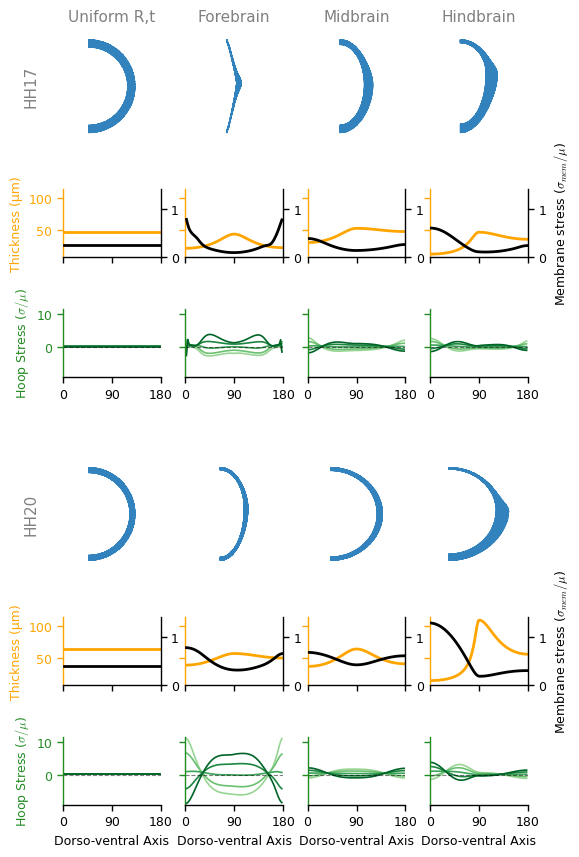

Master grid generated successfully!


In [ ]:
"""
fem_plane_stress.py

2D plane-stress finite element model of the cranial neural tube cross-section.

Model summary
-------------
- Geometry : half-annulus cross-section (exploits dorso-ventral symmetry).
  Inner radius r(θ) and wall thickness t(θ) are parametrized by three
  measurements (dorsal, lateral, ventral) interpolated with rational quadratic
  Bézier curves.  Geometric parameters are taken from measurements at HH17 and
  HH20 for each brain vesicle (FB, MB, HB) and a uniform-geometry control.

- Material  : linear elastic, nearly incompressible soft tissue.
  Shear modulus µ = 300 Pa, Poisson's ratio ν = 0.45 (set in mater.txt).
  Young's modulus E = 2µ(1+ν) ≈ 870 Pa.
  All stress outputs are normalised by µ so results are dimensionless.

- Loading   : uniform internal pressure P = 15 Pa applied as nodal forces
  on the inner-surface elements.

- Outputs   : hoop (circumferential) stress distribution through the wall,
  and membrane stress (thickness-averaged hoop stress) as a function of the
  dorso-ventral angle θ.  These are the data shown in Fig. S9 and Table S1.

Dependencies
------------
Run `pip install -r requirements_fem.txt` (solidspy, numpy, scipy, matplotlib).
SolidsPy reads four text files from the working directory: nodes.txt, eles.txt,
loads.txt, and mater.txt.  This script writes the first three; mater.txt must
contain a single line with the elastic constants:
    E   nu
    870 0.45
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from solidspy import solids_GUI


# ==============================================================================
# CONFIGURATION & DATASETS
# ==============================================================================

# Geometric parameters measured from segmented neural tube cross-sections.
# Columns: [r_top, r_mid, r_bot, t_top, t_mid, t_bot]
# r_* : inner-surface radius (µm) at dorsal pole (top), lateral midpoint (mid),
#        and ventral pole (bot).
# t_* : wall thickness (µm) at the same three landmarks.
# "uniform" rows use the mean radius and thickness as a circular-shell control.
CONDITIONS = {
    ("hh17", "uniform"): [250, 250, 250, 48, 48, 48],
    ("hh20", "uniform"): [500, 500, 500, 64, 64, 64],
    ("hh17", "fb"): [366, 86, 420, 22, 44, 23],
    ("hh20", "fb"): [569, 352, 715, 39, 57, 50],
    ("hh17", "mb"): [250, 150, 250, 31, 53, 48],
    ("hh20", "mb"): [500, 540, 500, 37, 64, 41],
    ("hh17", "hb"): [127, 106, 208, 13, 47, 36],
    ("hh20", "hb"): [351, 400, 371, 15, 109, 56],
}

def get_params_for_condition(stage, comp):
    """Returns (r_params, t_params) for a specific stage and component."""
    data = CONDITIONS.get((stage.lower(), comp.lower()))
    if data:
        r_params = tuple(data[:3])
        t_params = tuple(data[3:])
        return r_params, t_params
    else:
        print(f"Condition {stage} {comp} not found.")
        return None, None


# ==============================================================================
# MATH & INTERPOLATION
# ==============================================================================

def smooth_interp_asym(theta, y_top, y_mid, y_bot, weight=0.7071):
    """
    Rational Quadratic Bézier interpolation for the cross-section shape.

    Fits a smooth curve through three radial measurements (dorsal, lateral,
    ventral) using two rational quadratic Bézier segments joined at the
    lateral midpoint.

    weight=1/√2 ≈ 0.7071 is the special value that makes a rational quadratic
    Bézier arc an exact circular arc.  Lower weights (e.g. 0.4) produce a
    flatter 'mustache' profile, needed for strongly non-circular vesicles.
    """
    res = 500
    t = np.linspace(0, 1, res)

    # Segment 1: dorsal pole (0, y_top) → lateral midpoint (y_mid, 0)
    # Control point P1 is the corner of the bounding box; the weight pulls
    # the curve toward or away from that corner.
    P0, P1, P2 = np.array([0, y_top]), np.array([y_mid, y_top]), np.array([y_mid, 0])
    w = np.array([1.0, weight, 1.0])

    den1 = (1-t)**2 * w[0] + 2*(1-t)*t * w[1] + t**2 * w[2]
    x1 = ((1-t)**2 * w[0] * P0[0] + 2*(1-t)*t * w[1] * P1[0] + t**2 * w[2] * P2[0]) / den1
    y1 = ((1-t)**2 * w[0] * P0[1] + 2*(1-t)*t * w[1] * P1[1] + t**2 * w[2] * P2[1]) / den1

    # Segment 2: lateral midpoint (y_mid, 0) → ventral pole (0, -y_bot)
    P3, P4, P5 = np.array([y_mid, 0]), np.array([y_mid, -y_bot]), np.array([0, -y_bot])

    den2 = (1-t)**2 * w[0] + 2*(1-t)*t * w[1] + t**2 * w[2]
    x2 = ((1-t)**2 * w[0] * P3[0] + 2*(1-t)*t * w[1] * P4[0] + t**2 * w[2] * P5[0]) / den2
    y2 = ((1-t)**2 * w[0] * P3[1] + 2*(1-t)*t * w[1] * P4[1] + t**2 * w[2] * P5[1]) / den2

    # Convert the two Cartesian arc segments to polar (r, θ) and interpolate
    x_full = np.concatenate([x1, x2])
    y_full = np.concatenate([y1, y2])

    r_lookup = np.sqrt(x_full**2 + y_full**2)
    # atan2(x, y) so that θ=0 points upward (dorsal pole)
    theta_lookup = np.arctan2(x_full, y_full)

    idx = np.argsort(theta_lookup)
    return np.interp(theta, theta_lookup[idx], r_lookup[idx])

def get_spline_full_circle(y_top, y_mid, y_bot, theta_full, weight=0.7071):
    """
    Interpolates the dorsal half (0–π) with rational Bézier and mirrors for
    the ventral half (π–2π), giving a closed, bilaterally symmetric contour.
    """
    half_len = len(theta_full) // 2
    half_theta = np.linspace(0, np.pi, half_len)
    half_values = smooth_interp_asym(half_theta, y_top, y_mid, y_bot, weight)

    # Mirror: the left and right sides of the tube are assumed symmetric
    return np.concatenate([half_values, half_values[::-1]])


# ==============================================================================
# MESH & FEA GENERATION
# ==============================================================================

def generate_and_save_model(r_top, r_mid, r_bot, t_top, t_mid, t_bot, n_t, n_r, pressure, r_weight=0.7071, t_weight=0.7071):
    """
    Builds a 2D quadrilateral mesh of the half-annulus cross-section and
    writes the SolidsPy input files (nodes.txt, eles.txt, loads.txt).

    The half-model spans θ ∈ [−π/2, +π/2] (dorsal midline to ventral midline)
    and exploits bilateral left-right symmetry.

    Boundary conditions
    -------------------
    - Symmetry (x = 0, dorsal midline): u_x = 0 on all nodes at x ≈ 0.
    - Pinned corner at (x=0, y_min): u_y = 0 in addition, preventing rigid
      body translation while leaving the rest of the symmetry edge free to
      deform radially.

    Pressure loading
    ----------------
    Uniform internal pressure P is distributed as consistent nodal forces on
    the inner surface.  For each edge segment (n1, n2) of length ds with
    outward tangent (dx, dy), the force per unit length normal to the edge is:
        f_x = P * dy,  f_y = P * (-dx)
    Half the force is lumped to each endpoint node (equivalent nodal loading).
    """
    theta = np.linspace(-np.pi/2, np.pi/2, n_t, endpoint=True)
    xi = np.linspace(0, 1, n_r)   # radial interpolation parameter (0 = inner, 1 = outer)
    theta_geom = np.pi/2 - theta   # convert to the convention used by smooth_interp_asym

    r_in_array = smooth_interp_asym(theta_geom, r_top, r_mid, r_bot, weight=r_weight)
    t_array    = smooth_interp_asym(theta_geom, t_top, t_mid, t_bot, weight=t_weight)

    # Build node grid: n_r layers from inner to outer surface
    nodes_x, nodes_y = [], []
    for r_frac in xi:
        r_out = r_in_array + r_frac * t_array
        nodes_x.extend(r_out * np.cos(theta))
        nodes_y.extend(r_out * np.sin(theta))

    nodes_x, nodes_y = np.array(nodes_x), np.array(nodes_y)

    # Bilinear quadrilateral elements (SolidsPy element type 1)
    quads = []
    for i in range(n_r - 1):
        for j in range(n_t - 1):
            n1 = i*n_t + j
            n2 = i*n_t + (j + 1)
            n3 = (i + 1)*n_t + j
            n4 = (i + 1)*n_t + (j + 1)
            quads.append([n1, n3, n4, n2])

    quads = np.array(quads)
    min_y = np.min(nodes_y)

    # nodes.txt format: node_id  x  y  bc_x  bc_y
    # bc = -1 means the degree of freedom is constrained (Dirichlet), 0 = free
    with open("nodes.txt", 'w') as fnodes:
        for i, (x, y) in enumerate(zip(nodes_x, nodes_y)):
            bc_x = -1 if abs(x) < 1e-6 else 0            # symmetry: no horizontal displacement on midline
            bc_y = -1 if (abs(x) < 1e-6 and abs(y - min_y) < 1e-6) else 0  # pin one node against translation
            fnodes.write(f"{i} {x:.8f} {y:.8f} {bc_x} {bc_y}\n")

    # eles.txt format: elem_id  mat_id  section_id  n1 n2 n3 n4
    # mat_id=0 references row 0 of mater.txt (E=870 Pa, ν=0.45)
    with open("eles.txt", 'w') as feles:
        for i, quad in enumerate(quads):
            feles.write(f"{i} 1 0 {quad[0]} {quad[1]} {quad[2]} {quad[3]}\n")

    # Compute consistent nodal forces for uniform internal pressure on the inner surface
    # (inner surface = first n_t nodes, i.e., indices 0 … n_t-1)
    F_x, F_y = np.zeros(len(nodes_x)), np.zeros(len(nodes_y))
    for j in range(n_t - 1):
        n1, n2 = j, j + 1
        dx, dy = nodes_x[n2] - nodes_x[n1], nodes_y[n2] - nodes_y[n1]
        # Outward normal force per unit arc length: rotate tangent (dx, dy) by −90°
        fx_seg, fy_seg = pressure * dy, pressure * -dx
        F_x[n1] += 0.5 * fx_seg
        F_y[n1] += 0.5 * fy_seg
        F_x[n2] += 0.5 * fx_seg
        F_y[n2] += 0.5 * fy_seg

    # loads.txt format: node_id  Fx  Fy  (only non-zero entries)
    with open("loads.txt", 'w') as floads:
        for i in range(len(nodes_x)):
            if abs(F_x[i]) > 1e-8 or abs(F_y[i]) > 1e-8:
                floads.write(f"{i} {F_x[i]:.6f} {F_y[i]:.6f}\n")

    return nodes_x, nodes_y, quads


# ==============================================================================
# 0. GLOBAL FONT CONFIGURATION
# ==============================================================================
# Adjust these values to scale all fonts across the entire figure
FONTS = {
    'ticks': 9,    # numbers on the x and y axes
    'labels': 9,   # axis labels ("Thickness", "Hoop Stress", etc.)
    'titles': 11,  # column headers ("Forebrain", "Midbrain", etc.)
    'stages': 11,  # row labels ("HH17", "HH20")
    'global': 10   # base fallback font size
}


# ==============================================================================
# 1. DATA EXTRACTION (No Plotting)
# ==============================================================================
def compute_fea_data(r_params, t_params, r_weight=0.7071, t_weight=0.7071, mu=300, P=15.0, n_theta=80, n_r=20):
    """
    Runs the FEA for one geometric condition and returns post-processed results.

    Parameters
    ----------
    r_params  : (r_top, r_mid, r_bot) inner-surface radii in µm
    t_params  : (t_top, t_mid, t_bot) wall thicknesses in µm
    r_weight  : Bézier weight for the radius profile
    t_weight  : Bézier weight for the thickness profile
    mu        : shear modulus [Pa], used only for stress normalisation
    P         : internal pressure [Pa]
    n_theta   : number of nodes along the arc (circumferential resolution)
    n_r       : number of nodes through the wall (radial resolution)
    """
    r_top, r_mid, r_bot = r_params
    t_top, t_mid, t_bot = t_params

    nodes_x, nodes_y, quads = generate_and_save_model(
        r_top, r_mid, r_bot, t_top, t_mid, t_bot, n_theta, n_r, P, r_weight, t_weight
    )

    # SolidsPy solves the plane-stress linear elastic system and returns
    # nodal displacements and element-centroid stresses (σ_xx, σ_yy, τ_xy)
    disp, strain, stress = solids_GUI(plot_contours=False, compute_strains=True, folder="./")

    U_x, U_y = disp[:, 0], disp[:, 1]
    Sig_xx, Sig_yy, Tau_xy = stress[:, 0], stress[:, 1], stress[:, 2]

    # Split quads into triangles for matplotlib triplot
    triangles = []
    for q in quads:
        triangles.append([q[0], q[1], q[2]])
        triangles.append([q[0], q[2], q[3]])

    # --- Polar stress transformation ---
    # The hoop (circumferential) stress σ_θθ is the relevant load-bearing
    # component in a pressurised shell.  Given the polar angle φ at each node,
    # the stress tensor rotation gives:
    #   σ_hoop = σ_xx sin²φ + σ_yy cos²φ − 2τ_xy sinφ cosφ
    phi = np.arctan2(nodes_y, nodes_x)
    sin_p, cos_p = np.sin(phi), np.cos(phi)
    sigma_hoop = (Sig_xx * sin_p**2) + (Sig_yy * cos_p**2) - (2 * Tau_xy * sin_p * cos_p)

    # Reshape nodal arrays to (n_r, n_theta) grid for through-thickness integration
    x_grid    = nodes_x.reshape(n_r, n_theta)
    y_grid    = nodes_y.reshape(n_r, n_theta)
    hoop_grid = sigma_hoop.reshape(n_r, n_theta)

    # --- Membrane stress integral ---
    # The membrane (thickness-averaged) hoop stress is:
    #   σ_mem(θ) = (1/t) ∫_{r_in}^{r_out} σ_hoop(r, θ) dr
    # Numerically integrated with the trapezoidal rule along the radial axis.
    # This is the quantity tabulated in Table S1 and plotted in Fig. S9.
    r_grid = np.sqrt(x_grid**2 + y_grid**2)
    integral_hoop         = np.trapezoid(hoop_grid, x=r_grid, axis=0)
    local_thickness_array = r_grid[-1, :] - r_grid[0, :]
    avg_hoop_stress       = integral_hoop / local_thickness_array

    # Convert arc angle to dorso-ventral degrees (0° = dorsal, 180° = ventral)
    # and trim the boundary nodes (index 0 and -1) which carry constraint artifacts
    th_deg_plot = 90.0 - np.degrees(np.arctan2(y_grid[0, :], x_grid[0, :]))[1:-1]

    inner_x, inner_y = nodes_x[0:n_theta], nodes_y[0:n_theta]
    outer_x, outer_y = nodes_x[-n_theta:], nodes_y[-n_theta:]
    local_thick = np.sqrt((outer_x - inner_x)**2 + (outer_y - inner_y)**2)
    th_deg_geo  = 90.0 - np.degrees(np.arctan2(inner_y, inner_x))[1:-1]

    return {
        "nodes_x":    nodes_x,
        "nodes_y":    nodes_y,
        "triangles":  triangles,
        "th_deg_geo": th_deg_geo,
        "local_thick": local_thick[1:-1],
        "th_deg_plot": th_deg_plot,
        # Stresses normalised by µ to give dimensionless values (see Table S1)
        "avg_hoop":   avg_hoop_stress[1:-1] / mu,
        "hoop_grid":  hoop_grid[:, 1:-1] / mu,
        "n_r":        n_r,
    }


# ==============================================================================
# PLOTTING & STYLING
# ==============================================================================

def apply_l_frame_clean(ax, xlabel, ylabel, y_color='black', hide_y_ticks=False):
    """L-frame axis style: top and right spines removed, tick sizes from FONTS."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_color(y_color)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['left'].set_linewidth(1.0)

    ax.tick_params(axis='x', width=1.0, size=4, labelsize=FONTS['ticks'], colors='black')
    ax.tick_params(axis='y', width=1.0, size=4, labelsize=FONTS['ticks'], colors=y_color)

    if xlabel:
        ax.set_xlabel(xlabel, fontsize=FONTS['labels'], color='black')
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=FONTS['labels'], color=y_color)

    ax.set_xticks([0, 90, 180])
    ax.set_xlim(0, 180)

    if hide_y_ticks:
        ax.set_yticklabels([])


# ==============================================================================
# MASTER PLOTTING FUNCTION
# ==============================================================================
def plot_master_grid(all_results):
    """
    Builds the 2 × 4 master figure (Fig. S9).

    Layout: rows = HH17 / HH20, columns = Uniform / FB / MB / HB.
    Each cell contains three stacked panels:
      1. FEA mesh geometry (half-annulus cross-section)
      2. Wall thickness (orange) and membrane stress σ_mem/µ (black)
      3. Through-wall hoop stress σ/µ at five radial layers (green gradient)
    All panels share the same y-axis limits for fair visual comparison.
    """

    # Collect global y-axis limits across all conditions for uniform scaling
    all_thick = [np.concatenate((d["local_thick"],)) for d in all_results.values()]
    all_mem   = [np.concatenate((d["avg_hoop"],))    for d in all_results.values()]
    all_hoop  = [d["hoop_grid"].flatten()            for d in all_results.values()]

    ylim_thick = [np.min(all_thick) - 5, np.max(all_thick) + 5]
    ylim_mem   = [0, np.max(all_mem) * 1.1]
    h_min, h_max = np.min(all_hoop), np.max(all_hoop)
    ylim_hoop  = [h_min - 0.5, h_max + 0.5]

    plt.rcParams.update({
        'font.size': FONTS['global'],
        'axes.linewidth': 1.0,
        'mathtext.fontset': 'cm'
    })

    fig = plt.figure(figsize=(6, 10), dpi=100)
    outer_gs = gridspec.GridSpec(2, 4, figure=fig, wspace=0.25, hspace=0.25)

    stages      = ["hh17", "hh20"]
    comps       = ["uniform", "fb", "mb", "hb"]
    comp_titles = ["Uniform R,t", "Forebrain", "Midbrain", "Hindbrain"]

    for row_idx, stage in enumerate(stages):
        for col_idx, comp in enumerate(comps):
            data = all_results.get((stage, comp))
            if not data:
                continue

            show_left_ylabel  = (col_idx == 0)
            show_right_ylabel = (col_idx == 3)
            show_xlabel       = (row_idx == 1)

            inner_gs = gridspec.GridSpecFromSubplotSpec(
                3, 1,
                subplot_spec=outer_gs[row_idx, col_idx],
                hspace=0.65,
                wspace=0.65,
                height_ratios=[1.5, 1, 1]
            )

            # Panel 1: mesh geometry
            ax1 = fig.add_subplot(inner_gs[0])
            ax1.triplot(data["nodes_x"], data["nodes_y"], data["triangles"], color='#3182bd', lw=0.6)
            ax1.axis('equal')
            ax1.axis('off')

            if row_idx == 0:
                ax1.set_title(comp_titles[col_idx], fontsize=FONTS['titles'], pad=10, color='gray')
            if col_idx == 0:
                ax1.text(-0.4, 0.5, stage.upper(), transform=ax1.transAxes,
                         fontsize=FONTS['stages'], rotation=90, va='center', color='gray')

            # Panel 2: thickness (left axis, orange) + membrane stress (right axis, black)
            ax2 = fig.add_subplot(inner_gs[1])
            ax2.plot(data["th_deg_geo"], data["local_thick"], color='orange', lw=2.0)

            t_label = "Thickness (μm)" if show_left_ylabel else ""
            apply_l_frame_clean(ax2, "", t_label, y_color='orange', hide_y_ticks=not show_left_ylabel)
            ax2.tick_params(labelbottom=False)
            ax2.set_ylim(ylim_thick)

            ax2_twin = ax2.twinx()
            ax2_twin.plot(data["th_deg_plot"], data["avg_hoop"], color='black', lw=2.0)

            ax2_twin.spines['top'].set_visible(False)
            ax2_twin.spines['left'].set_visible(False)
            ax2_twin.spines['bottom'].set_visible(False)
            ax2_twin.spines['right'].set_visible(True)
            ax2_twin.spines['right'].set_color('black')
            ax2_twin.spines['right'].set_linewidth(1.0)
            ax2_twin.tick_params(axis='y', width=1.0, size=4, labelsize=FONTS['ticks'], colors='black')

            if show_right_ylabel:
                ax2_twin.set_ylabel(r"Membrane stress ($\sigma_{mem} / \mu$)", color='black', fontsize=FONTS['labels'])

            ax2_twin.set_ylim(ylim_mem)

            # Panel 3: through-wall hoop stress at 5 radial layers (inner → outer)
            ax3 = fig.add_subplot(inner_gs[2], sharex=ax2)
            layer_indices = np.linspace(0, data["n_r"] - 1, 5).astype(int)
            colors = plt.cm.Greens(np.linspace(0.4, 0.9, len(layer_indices)))

            for i, l_idx in enumerate(layer_indices):
                ax3.plot(data["th_deg_plot"], data["hoop_grid"][l_idx], color=colors[i], lw=1.2)

            ax3.axhline(0, color='black', linestyle='--', lw=0.8, alpha=0.5)

            h_label = r"Hoop Stress ($\sigma / \mu$)" if show_left_ylabel else ""
            x_label = r"Dorso-ventral Axis" if show_xlabel else ""

            apply_l_frame_clean(ax3, x_label, h_label, y_color='forestgreen', hide_y_ticks=not show_left_ylabel)
            ax3.set_ylim(ylim_hoop)

    plt.savefig("Master_FEA_Grid_Clean.svg", format='svg', bbox_inches='tight')
    plt.show()
    print("Master grid generated successfully!")


# ==============================================================================
# EXECUTION
# ==============================================================================
if __name__ == "__main__":
    print("Phase 1: Running FEA for all conditions (this may take a minute)...")
    all_fea_results = {}

    stages = ["hh17", "hh20"]
    comps  = ["uniform", "fb", "mb", "hb"]

    for stage in stages:
        for comp in comps:
            rp, tp = get_params_for_condition(stage, comp)
            if not rp:
                continue

            print(f"  -> Solving {stage.upper()} {comp.upper()}...")

            # The Bézier weight controls how non-circular the cross-section is.
            # A squish ratio r_mid/r_top < 0.5 indicates a strongly elongated
            # vesicle (e.g. HH17 forebrain), which needs a lower weight to
            # avoid the curve overshooting at the lateral flanks.
            squish = rp[1] / rp[0]
            suggested_weight = 0.45 if squish < 0.5 else 0.7071

            if stage == "hh17" and comp == "fb":
                # HH17 forebrain is highly flattened; default weights produce
                # a self-intersecting contour.  A weight of 0.1 was tuned
                # manually to match the measured outline.
                suggested_weight = 0.1
                print("     [Custom weight 0.1 applied to HH17 FB]")

            data = compute_fea_data(rp, tp, r_weight=suggested_weight)
            all_fea_results[(stage, comp)] = data

    print("\nPhase 2: Compiling master grid with uniform axes...")
    plot_master_grid(all_fea_results)